# Notebook 07 - Customer Segmentation using RFM Analysis

## Objective
The goal of this notebook is to perform **customer segmentation** on the Olist e-commerce dataset using the **RFM framework**.

RFM stands for:
- **Recency**: How recently a customer made a purchase
- **Frequency**: How often a customer places orders
- **Monetary**: How much revenue the customer generates

## Business Value
RFM segmentation helps the business:
- identify high-value and loyal customers
- detect inactive or at-risk customers
- understand repeat purchase behavior
- design targeted retention and reactivation strategies
- prioritize marketing efforts based on customer value

## Notebook Scope
In this notebook, we will:
- prepare a clean customer transaction base
- calculate Recency, Frequency, and Monetary values
- generate RFM scores
- create customer segments
- analyze the size and value of each segment

In [2]:
# ======================================================
# Section 2 - Import Libraries
# ======================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

In [3]:
# ======================================================
# Section 3 - Define Paths and Load Files
# ======================================================

DATA_DIR = Path(r"C:\Users\divya\Downloads\Retail-Intelligence-Platform\data\raw")

customers_path = DATA_DIR / "olist_customers_dataset.csv"
orders_path = DATA_DIR / "olist_orders_dataset.csv"
payments_path = DATA_DIR / "olist_order_payments_dataset.csv"

customers = pd.read_csv(customers_path)
orders = pd.read_csv(orders_path)
payments = pd.read_csv(payments_path)

print("Customers shape:", customers.shape)
print("Orders shape   :", orders.shape)
print("Payments shape :", payments.shape)

display(customers.head())
display(orders.head())
display(payments.head())

Customers shape: (99441, 5)
Orders shape   : (99441, 8)
Payments shape : (103886, 5)


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [4]:
# ======================================================
# Section 4 - Inspect Relevant Columns
# ======================================================

print("Customers columns:")
print(customers.columns.tolist())

print("\nOrders columns:")
print(orders.columns.tolist())

print("\nPayments columns:")
print(payments.columns.tolist())

Customers columns:
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

Orders columns:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

Payments columns:
['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']


In [5]:
# ======================================================
# Section 5 - Convert Date Columns
# ======================================================

orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"],
    errors="coerce"
)

print("Null order_purchase_timestamp values:", orders["order_purchase_timestamp"].isna().sum())

display(
    orders[["order_id", "customer_id", "order_status", "order_purchase_timestamp"]].head()
)

Null order_purchase_timestamp values: 0


,order_id,customer_id,order_status,order_purchase_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39


In [6]:
# ======================================================
# Section 6 - Filter Delivered Orders
# ======================================================

orders_delivered = orders.loc[
    orders["order_status"] == "delivered",
    ["order_id", "customer_id", "order_purchase_timestamp", "order_status"]
].copy()

print("Delivered orders shape:", orders_delivered.shape)
display(orders_delivered.head())

Delivered orders shape: (96478, 4)


,order_id,customer_id,order_purchase_timestamp,order_status
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,delivered
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,delivered
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,delivered
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,2017-11-18 19:28:06,delivered
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2018-02-13 21:18:39,delivered


In [7]:
# ======================================================
# Section 7 - Aggregate Payments at Order Level
# ======================================================

payments_agg = (
    payments.groupby("order_id", as_index=False)["payment_value"]
    .sum()
)

print("Aggregated payments shape:", payments_agg.shape)
display(payments_agg.head())

Aggregated payments shape: (99440, 2)


,order_id,payment_value
0,00010242fe8c5a6d1ba2dd792cb16214,72.19
1,00018f77f2f0320c557190d7a144bdd3,259.83
2,000229ec398224ef6ca0657da4fc703e,216.87
3,00024acbcdf0a6daa1e931b038114c75,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04


In [8]:
# ======================================================
# Section 8 - Build Customer Transaction Base
# ======================================================

rfm_base = (
    orders_delivered
    .merge(customers[["customer_id", "customer_unique_id"]], on="customer_id", how="left")
    .merge(payments_agg, on="order_id", how="left")
)

print("RFM base shape:", rfm_base.shape)
display(rfm_base.head())

RFM base shape: (96478, 6)


,order_id,customer_id,order_purchase_timestamp,order_status,customer_unique_id,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,delivered,7c396fd4830fd04220f754e42b4e5bff,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,delivered,af07308b275d755c9edb36a90c618231,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,delivered,3a653a41f6f9fc3d2a113cf8398680e8,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,2017-11-18 19:28:06,delivered,7c142cf63193a1473d2e66489a9ae977,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2018-02-13 21:18:39,delivered,72632f0f9dd73dfee390c9b22eb56dd6,28.62


In [9]:
# ======================================================
# Section 9 - Null Check
# ======================================================

null_summary = rfm_base.isnull().sum().sort_values(ascending=False)
display(null_summary)

print("\nRows with null payment_value:", rfm_base["payment_value"].isna().sum())
print("Rows with null customer_unique_id:", rfm_base["customer_unique_id"].isna().sum())
print("Rows with null order_purchase_timestamp:", rfm_base["order_purchase_timestamp"].isna().sum())

payment_value               1
order_id                    0
customer_id                 0
order_purchase_timestamp    0
order_status                0
customer_unique_id          0
dtype: int64


Rows with null payment_value: 1
Rows with null customer_unique_id: 0
Rows with null order_purchase_timestamp: 0


In [10]:
# ======================================================
# Section 10 - Drop Critical Nulls
# ======================================================

rfm_base = rfm_base.dropna(
    subset=["customer_unique_id", "order_purchase_timestamp", "payment_value"]
).copy()

print("RFM base shape after dropping critical nulls:", rfm_base.shape)
display(rfm_base.head())

RFM base shape after dropping critical nulls: (96477, 6)


,order_id,customer_id,order_purchase_timestamp,order_status,customer_unique_id,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,delivered,7c396fd4830fd04220f754e42b4e5bff,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,delivered,af07308b275d755c9edb36a90c618231,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,delivered,3a653a41f6f9fc3d2a113cf8398680e8,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,2017-11-18 19:28:06,delivered,7c142cf63193a1473d2e66489a9ae977,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2018-02-13 21:18:39,delivered,72632f0f9dd73dfee390c9b22eb56dd6,28.62


In [11]:
# ======================================================
# Section 11 - Define Snapshot Date
# ======================================================

print("Min purchase date:", rfm_base["order_purchase_timestamp"].min())
print("Max purchase date:", rfm_base["order_purchase_timestamp"].max())

snapshot_date = rfm_base["order_purchase_timestamp"].max() + pd.Timedelta(days=1)

print("Snapshot date for Recency calculation:", snapshot_date)

Min purchase date: 2016-10-03 09:44:50
Max purchase date: 2018-08-29 15:00:37
Snapshot date for Recency calculation: 2018-08-30 15:00:37


In [12]:
# ======================================================
# Section 12 - Calculate RFM Metrics
# ======================================================

rfm = (
    rfm_base.groupby("customer_unique_id")
    .agg({
        "order_purchase_timestamp": lambda x: (snapshot_date - x.max()).days,
        "order_id": "nunique",
        "payment_value": "sum"
    })
    .reset_index()
)

rfm.columns = ["customer_unique_id", "Recency", "Frequency", "Monetary"]

print("RFM table shape:", rfm.shape)
display(rfm.head())

RFM table shape: (93357, 4)


,customer_unique_id,Recency,Frequency,Monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19
2,0000f46a3911fa3c0805444483337064,537,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89


In [13]:
# ======================================================
# Section 13 - RFM Summary Statistics
# ======================================================

display(rfm.describe())

print("\nTop 10 highest monetary customers:")
display(rfm.sort_values("Monetary", ascending=False).head(10))

print("\nTop 10 highest frequency customers:")
display(rfm.sort_values("Frequency", ascending=False).head(10))

,Recency,Frequency,Monetary
count,"93,357.00","93,357.00","93,357.00"
mean,237.94,1.03,165.20
std,152.58,0.21,226.31
min,1.00,1.00,9.59
25%,114.00,1.00,63.06
50%,219.00,1.00,107.78
75%,346.00,1.00,182.56
max,695.00,15.00,"13,664.08"



Top 10 highest monetary customers:


,customer_unique_id,Recency,Frequency,Monetary
3724,0a0a92112bd4c708ca5fde585afaa872,334,1,"13,664.08"
79635,da122df9eeddfedc1dc1f5349a1a690c,515,2,"7,571.63"
43168,763c8b1c9c68a0229c42c9fc6f662b93,46,1,"7,274.88"
80462,dc4802a71eae9be1dd28f5d788ceb526,563,1,"6,929.31"
25436,459bef486812aa25204be022145caa62,35,1,"6,922.21"
93080,ff4159b92c40ebe40454e3e6a7c35ed6,462,1,"6,726.66"
23411,4007669dec559734d6f53e029e360987,279,1,"6,081.54"
87147,eebb5dda148d3893cdaf5b5ca3040ccb,498,1,"4,764.34"
26640,48e1ac109decbb87765a3eade6854098,69,1,"4,681.78"
73126,c8460e4251689ba205045f3ea17884a1,22,4,"4,655.91"



Top 10 highest frequency customers:


,customer_unique_id,Recency,Frequency,Monetary
51430,8d50f5eadf50201ccdcedfb9e2ac8455,9,15,879.27
22779,3e43e6105506432c953e165fb2acf44c,183,9,"1,172.66"
36706,6469f99c1f9dfae7733b25662e7f1782,63,7,758.83
10060,1b6c7548a2a1f9037c1fd3ddfed95f33,197,7,959.01
73920,ca77025e7201e3b30c44b472ff346268,90,7,"1,122.72"
26257,47c1a3033b8b77b3ab6e109eb4d5fdf3,217,6,944.21
80537,dc813062e0fc23409cd255f7f53c7074,7,6,"1,094.63"
36500,63cfc61cee11cbe306bff5857d00bfe4,93,6,826.32
87884,f0e310a6839dce9de1638e0fe5ab282a,147,6,540.69
6964,12f5d6e1cbf93dafd9dcc19095df0b3d,601,6,110.72


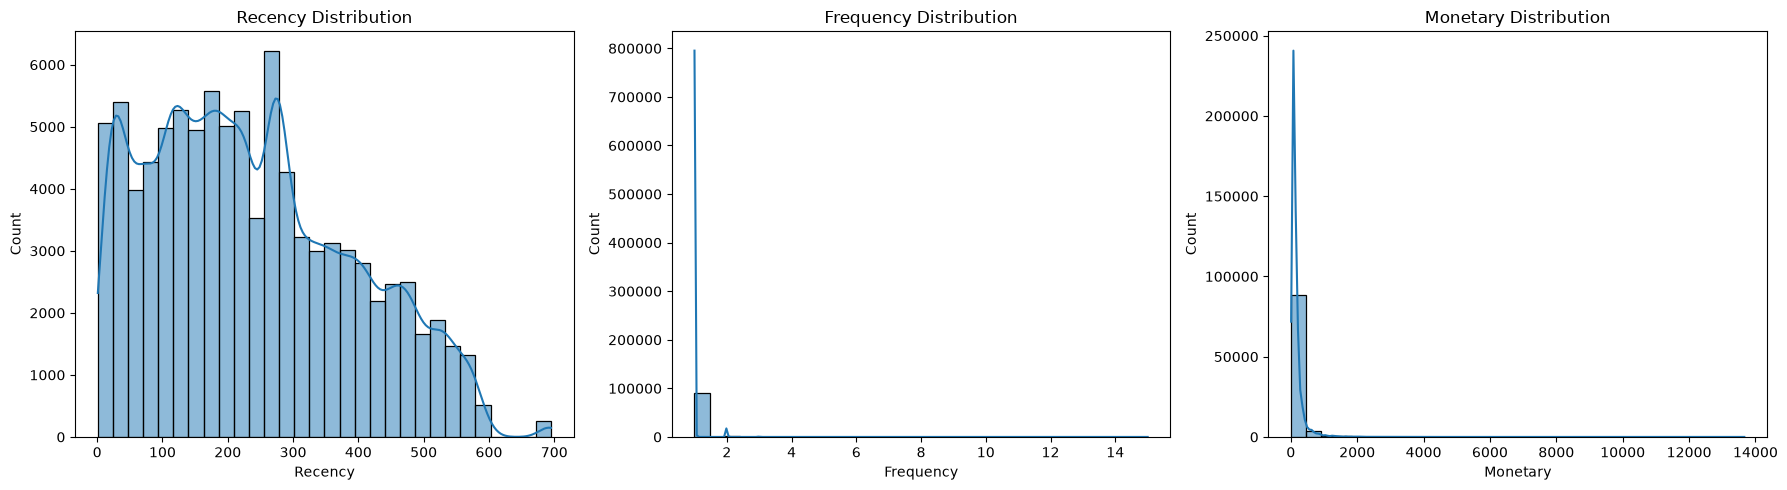

In [14]:
# ======================================================
# Section 14 - Visualize RFM Distributions
# ======================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(rfm["Recency"], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Recency Distribution")

sns.histplot(rfm["Frequency"], bins=30, kde=True, ax=axes[1])
axes[1].set_title("Frequency Distribution")

sns.histplot(rfm["Monetary"], bins=30, kde=True, ax=axes[2])
axes[2].set_title("Monetary Distribution")

plt.tight_layout()
plt.show()

In [15]:
# ======================================================
# Section 15 - Create RFM Scores
# ======================================================

# Recency score: lower Recency = better => reverse scoring
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    q=5,
    labels=[5, 4, 3, 2, 1]
).astype(int)

# Frequency score: higher Frequency = better
rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

# Monetary score: higher Monetary = better
rfm["M_Score"] = pd.qcut(
    rfm["Monetary"],
    q=5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

# Combined RFM score string
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str) +
    rfm["F_Score"].astype(str) +
    rfm["M_Score"].astype(str)
)

# Numeric total score
rfm["RFM_Total"] = rfm["R_Score"] + rfm["F_Score"] + rfm["M_Score"]

print("RFM table with scores:")
display(rfm.head())

RFM table with scores:


,customer_unique_id,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Total
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,4,1,4,414,9
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,4,1,1,411,6
2,0000f46a3911fa3c0805444483337064,537,1,86.22,1,1,2,112,4
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,2,1,1,211,4
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,2,1,4,214,7


In [16]:
# ======================================================
# Section 16 - Create Customer Segments
# ======================================================

def assign_rfm_segment(row):
    r = row["R_Score"]
    f = row["F_Score"]
    m = row["M_Score"]

    # Champions: very recent + frequent + high spend
    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"

    # Loyal Customers: strong frequency and generally good recency / spend
    elif r >= 3 and f >= 4 and m >= 3:
        return "Loyal Customers"

    # Big Spenders: strong monetary but not necessarily very frequent
    elif m >= 4 and r >= 3:
        return "Big Spenders"

    # Potential Loyalists: recent and moderate frequency/spend
    elif r >= 4 and f >= 2 and m >= 2:
        return "Potential Loyalists"

    # Recent Customers: purchased recently but low frequency so far
    elif r >= 4 and f <= 2:
        return "Recent Customers"

    # Promising: fairly recent, low-moderate frequency
    elif r == 3 and f >= 2:
        return "Promising"

    # At Risk: used to buy more / spend more but not recent
    elif r <= 2 and (f >= 3 or m >= 3):
        return "At Risk"

    # Lost Customers: old, low frequency, low spend
    elif r <= 2 and f <= 2 and m <= 2:
        return "Lost Customers"

    # Others
    else:
        return "Need Attention"

rfm["Segment"] = rfm.apply(assign_rfm_segment, axis=1)

print("Segment counts:")
display(rfm["Segment"].value_counts())
display(rfm.head())

Segment counts:


Segment
At Risk                30900
Big Spenders           13208
Potential Loyalists     8724
Promising               7565
Loyal Customers         7548
Need Attention          6647
Champions               6493
Lost Customers          6315
Recent Customers        5957
Name: count, dtype: int64

,customer_unique_id,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Total,Segment
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,4,1,4,414,9,Big Spenders
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,4,1,1,411,6,Recent Customers
2,0000f46a3911fa3c0805444483337064,537,1,86.22,1,1,2,112,4,Lost Customers
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,2,1,1,211,4,Lost Customers
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,2,1,4,214,7,At Risk


In [17]:
# ======================================================
# Section 17 - Segment Summary Table
# ======================================================

segment_summary = (
    rfm.groupby("Segment")
    .agg(
        Customers=("customer_unique_id", "count"),
        Avg_Recency=("Recency", "mean"),
        Avg_Frequency=("Frequency", "mean"),
        Avg_Monetary=("Monetary", "mean"),
        Total_Revenue=("Monetary", "sum")
    )
    .reset_index()
)

segment_summary["Customer_%"] = (
    segment_summary["Customers"] / segment_summary["Customers"].sum() * 100
).round(2)

segment_summary["Revenue_%"] = (
    segment_summary["Total_Revenue"] / segment_summary["Total_Revenue"].sum() * 100
).round(2)

segment_summary = segment_summary.sort_values(
    by="Total_Revenue",
    ascending=False
).reset_index(drop=True)

display(segment_summary)

,Segment,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue,Customer_%,Revenue_%
0,At Risk,30900,394.62,1.03,187.75,"5,801,348.10",33.10,37.62
1,Big Spenders,13208,133.21,1.00,295.72,"3,905,814.23",14.15,25.33
2,Champions,6493,91.11,1.18,312.13,"2,026,656.84",6.96,13.14
3,Loyal Customers,7548,170.11,1.10,183.71,"1,386,671.84",8.09,8.99
4,Potential Loyalists,8724,89.74,1.01,83.85,"731,550.25",9.34,4.74
5,Promising,7565,220.22,1.00,65.27,"493,787.11",8.10,3.20
6,Recent Customers,5957,91.11,1.00,64.98,"387,084.37",6.38,2.51
7,Lost Customers,6315,396.82,1.00,55.83,"352,568.09",6.76,2.29
8,Need Attention,6647,133.39,1.00,50.70,"336,980.94",7.12,2.19


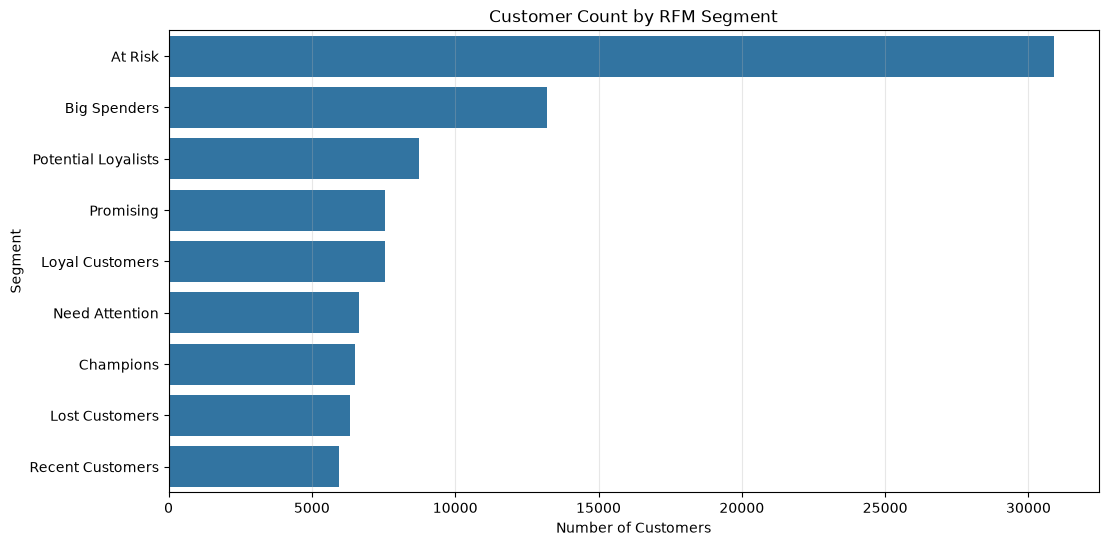

In [18]:
# ======================================================
# Section 18 - Customer Count by Segment
# ======================================================

plt.figure(figsize=(12, 6))
sns.countplot(
    data=rfm,
    y="Segment",
    order=rfm["Segment"].value_counts().index
)
plt.title("Customer Count by RFM Segment")
plt.xlabel("Number of Customers")
plt.ylabel("Segment")
plt.grid(axis="x", alpha=0.3)
plt.show()

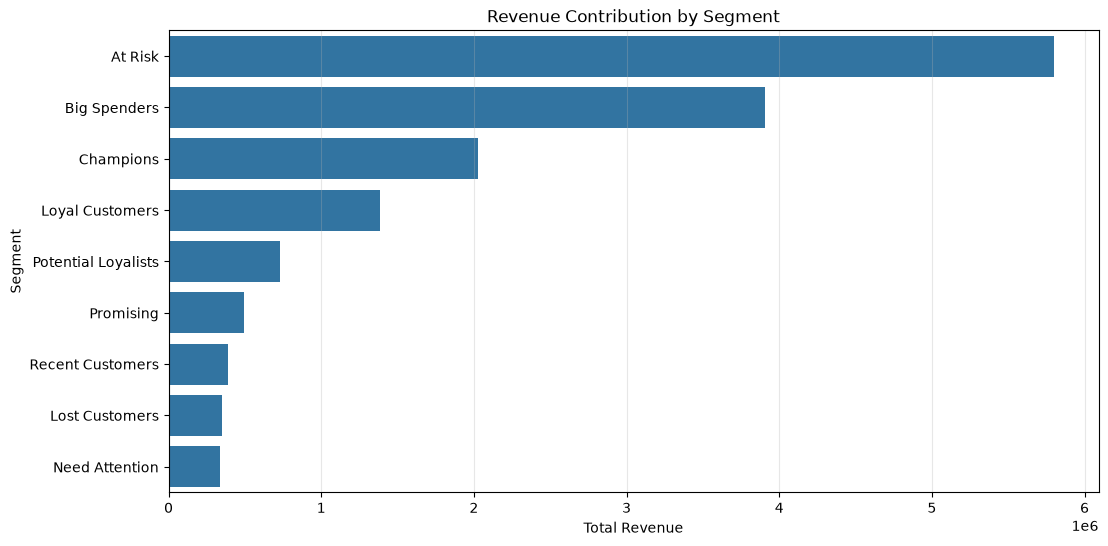

,Segment,Monetary
0,At Risk,"5,801,348.10"
1,Big Spenders,"3,905,814.23"
2,Champions,"2,026,656.84"
4,Loyal Customers,"1,386,671.84"
6,Potential Loyalists,"731,550.25"
7,Promising,"493,787.11"
8,Recent Customers,"387,084.37"
3,Lost Customers,"352,568.09"
5,Need Attention,"336,980.94"


In [19]:
# ======================================================
# Section 19 - Revenue Contribution by Segment
# ======================================================

segment_revenue = (
    rfm.groupby("Segment", as_index=False)["Monetary"]
    .sum()
    .sort_values("Monetary", ascending=False)
)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=segment_revenue,
    x="Monetary",
    y="Segment"
)
plt.title("Revenue Contribution by Segment")
plt.xlabel("Total Revenue")
plt.ylabel("Segment")
plt.grid(axis="x", alpha=0.3)
plt.show()

display(segment_revenue)

In [20]:
# ======================================================
# Section 20 - Average RFM Metrics by Segment
# ======================================================

avg_rfm_by_segment = (
    rfm.groupby("Segment")
    .agg({
        "Recency": "mean",
        "Frequency": "mean",
        "Monetary": "mean"
    })
    .round(2)
    .sort_values("Monetary", ascending=False)
)

display(avg_rfm_by_segment)

,Recency,Frequency,Monetary
Segment,,,
Champions,91.11,1.18,312.13
Big Spenders,133.21,1.00,295.72
At Risk,394.62,1.03,187.75
Loyal Customers,170.11,1.10,183.71
Potential Loyalists,89.74,1.01,83.85
Promising,220.22,1.00,65.27
Recent Customers,91.11,1.00,64.98
Lost Customers,396.82,1.00,55.83
Need Attention,133.39,1.00,50.70


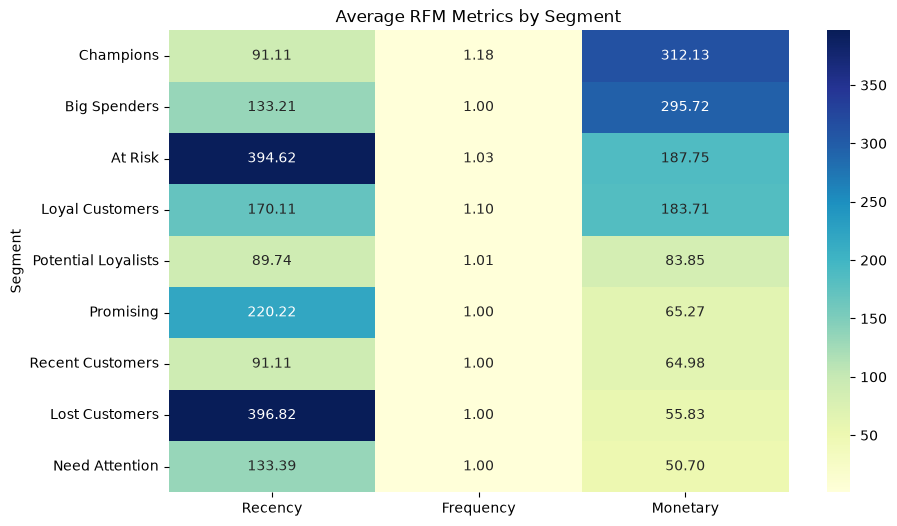

In [21]:
# ======================================================
# Section 21 - Heatmap of Average RFM Metrics
# ======================================================

plt.figure(figsize=(10, 6))
sns.heatmap(
    avg_rfm_by_segment,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu"
)
plt.title("Average RFM Metrics by Segment")
plt.show()

In [22]:
# ======================================================
# Section 22 - Top High-Value Customers
# ======================================================

top_customers = rfm.sort_values(
    by="Monetary",
    ascending=False
).head(20)

display(top_customers)

,customer_unique_id,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Total,Segment
3724,0a0a92112bd4c708ca5fde585afaa872,334,1,"13,664.08",2,1,5,215,8,At Risk
79635,da122df9eeddfedc1dc1f5349a1a690c,515,2,"7,571.63",1,5,5,155,11,At Risk
43168,763c8b1c9c68a0229c42c9fc6f662b93,46,1,"7,274.88",5,3,5,535,13,Big Spenders
80462,dc4802a71eae9be1dd28f5d788ceb526,563,1,"6,929.31",1,5,5,155,11,At Risk
25436,459bef486812aa25204be022145caa62,35,1,"6,922.21",5,2,5,525,12,Big Spenders
93080,ff4159b92c40ebe40454e3e6a7c35ed6,462,1,"6,726.66",1,5,5,155,11,At Risk
23411,4007669dec559734d6f53e029e360987,279,1,"6,081.54",2,2,5,225,9,At Risk
87147,eebb5dda148d3893cdaf5b5ca3040ccb,498,1,"4,764.34",1,5,5,155,11,At Risk
26640,48e1ac109decbb87765a3eade6854098,69,1,"4,681.78",5,2,5,525,12,Big Spenders
73126,c8460e4251689ba205045f3ea17884a1,22,4,"4,655.91",5,5,5,555,15,Champions


In [23]:
# ======================================================
# Section 23 - At Risk and Lost Customers
# ======================================================

at_risk_customers = rfm[rfm["Segment"] == "At Risk"].copy()
lost_customers = rfm[rfm["Segment"] == "Lost Customers"].copy()

print("At Risk customers:", at_risk_customers.shape[0])
print("Lost customers   :", lost_customers.shape[0])

display(at_risk_customers.head())
display(lost_customers.head())

At Risk customers: 30900
Lost customers   : 6315


,customer_unique_id,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Total,Segment
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,2,1,4,214,7,At Risk
8,0005e1862207bf6ccc02e4228effd9a0,543,1,150.12,1,1,4,114,6,At Risk
11,00082cbe03e478190aadbea78542e933,283,1,126.26,2,1,3,213,6,At Risk
14,000a5ad9c4601d2bbdd9ed765d5213b3,384,1,91.28,1,1,3,113,5,At Risk
18,000de6019bb59f34c099a907c151d855,377,1,257.44,2,1,5,215,8,At Risk


,customer_unique_id,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Total,Segment
2,0000f46a3911fa3c0805444483337064,537,1,86.22,1,1,2,112,4,Lost Customers
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,2,1,1,211,4,Lost Customers
10,0006fdc98a402fceb4eb0ee528f6a8d4,408,1,29.00,1,1,1,111,3,Lost Customers
15,000bfa1d2f1a41876493be685390d6d3,335,1,46.85,2,1,1,211,4,Lost Customers
26,00115fc7123b5310cf6d3a3aa932699e,585,1,76.11,1,1,2,112,4,Lost Customers


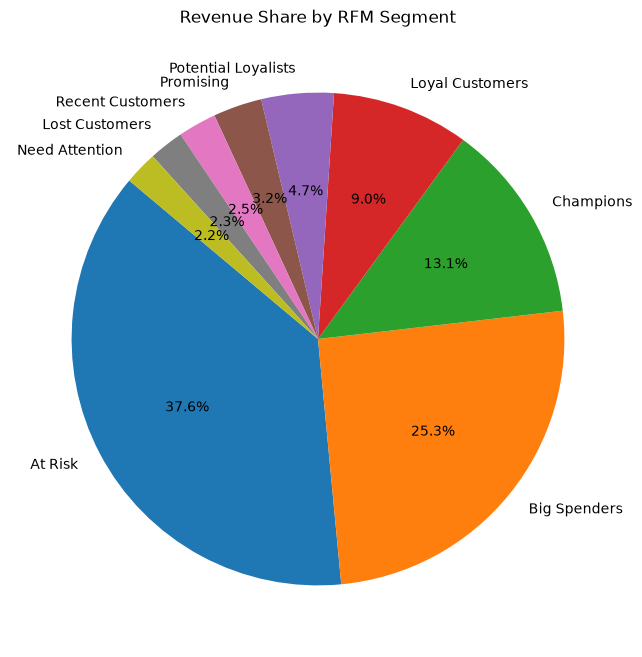

In [24]:
# ======================================================
# Section 24 - Segment Revenue Share
# ======================================================

segment_revenue_share = (
    rfm.groupby("Segment")["Monetary"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 8))
plt.pie(
    segment_revenue_share.values,
    labels=segment_revenue_share.index,
    autopct="%1.1f%%",
    startangle=140
)
plt.title("Revenue Share by RFM Segment")
plt.show()

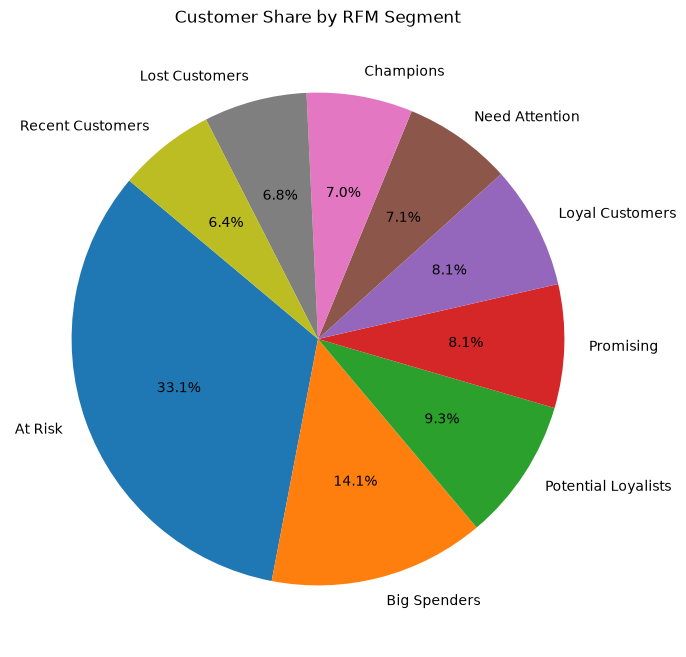

In [25]:
# ======================================================
# Section 25 - Segment Customer Share
# ======================================================

segment_customer_share = (
    rfm["Segment"]
    .value_counts()
)

plt.figure(figsize=(10, 8))
plt.pie(
    segment_customer_share.values,
    labels=segment_customer_share.index,
    autopct="%1.1f%%",
    startangle=140
)
plt.title("Customer Share by RFM Segment")
plt.show()

In [26]:
# ======================================================
# Section 26 - Prepare RFM for Clustering
# ======================================================

rfm_cluster = rfm[["customer_unique_id", "Recency", "Frequency", "Monetary"]].copy()

# Add 1 to avoid log(0) issues
rfm_cluster["Recency_log"] = np.log1p(rfm_cluster["Recency"])
rfm_cluster["Frequency_log"] = np.log1p(rfm_cluster["Frequency"])
rfm_cluster["Monetary_log"] = np.log1p(rfm_cluster["Monetary"])

cluster_features = rfm_cluster[["Recency_log", "Frequency_log", "Monetary_log"]]

scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_features)

print("Scaled feature shape:", cluster_scaled.shape)
display(rfm_cluster.head())

Scaled feature shape: (93357, 3)


,customer_unique_id,Recency,Frequency,Monetary,Recency_log,Frequency_log,Monetary_log
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,4.73,0.69,4.96
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,4.75,0.69,3.34
2,0000f46a3911fa3c0805444483337064,537,1,86.22,6.29,0.69,4.47
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,5.77,0.69,3.80
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,5.67,0.69,5.29


In [27]:
# ======================================================
# Section 27 - KMeans Clustering
# ======================================================

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm_cluster["Cluster"] = kmeans.fit_predict(cluster_scaled)

display(rfm_cluster.head())
print("Cluster counts:")
display(rfm_cluster["Cluster"].value_counts().sort_index())

,customer_unique_id,Recency,Frequency,Monetary,Recency_log,Frequency_log,Monetary_log,Cluster
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,4.73,0.69,4.96,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,4.75,0.69,3.34,1
2,0000f46a3911fa3c0805444483337064,537,1,86.22,6.29,0.69,4.47,1
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,5.77,0.69,3.80,1
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,5.67,0.69,5.29,0


Cluster counts:


Cluster
0    32185
1    42287
2     2801
3    16084
Name: count, dtype: int64

In [28]:
# ======================================================
# Section 28 - Cluster Summary
# ======================================================

cluster_summary = (
    rfm_cluster.groupby("Cluster")
    .agg({
        "Recency": "mean",
        "Frequency": "mean",
        "Monetary": "mean",
        "customer_unique_id": "count"
    })
    .rename(columns={"customer_unique_id": "Customers"})
    .round(2)
    .reset_index()
)

display(cluster_summary)

,Cluster,Recency,Frequency,Monetary,Customers
0,0,272.48,1.00,295.78,32185
1,1,287.33,1.00,68.21,42287
2,2,220.29,2.11,308.59,2801
3,3,42.02,1.00,133.91,16084


In [29]:
# ======================================================
# Section 29 - Merge Cluster Labels Back
# ======================================================

rfm = rfm.merge(
    rfm_cluster[["customer_unique_id", "Cluster"]],
    on="customer_unique_id",
    how="left"
)

display(rfm.head())

print("Cluster distribution:")
display(rfm["Cluster"].value_counts().sort_index())

,customer_unique_id,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Total,Segment,Cluster
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,4,1,4,414,9,Big Spenders,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,4,1,1,411,6,Recent Customers,1
2,0000f46a3911fa3c0805444483337064,537,1,86.22,1,1,2,112,4,Lost Customers,1
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,2,1,1,211,4,Lost Customers,1
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,2,1,4,214,7,At Risk,0


Cluster distribution:


Cluster
0    32185
1    42287
2     2801
3    16084
Name: count, dtype: int64

In [30]:
print(rfm.columns.tolist())

['customer_unique_id', 'Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score', 'RFM_Score', 'RFM_Total', 'Segment', 'Cluster']


In [31]:
# ======================================================
# Section 31 - Export Repeat Purchase Summary
# FINAL VERSION
# ======================================================

import csv
from pathlib import Path
import pandas as pd

# 1) Validate source dataframe
if "rfm" not in globals():
    raise ValueError("rfm dataframe not found. Run the RFM section first.")

required_cols = ["customer_unique_id", "Frequency", "Monetary"]
missing_cols = [c for c in required_cols if c not in rfm.columns]

if missing_cols:
    raise ValueError(f"Missing required columns in rfm dataframe: {missing_cols}")

# 2) Build repeat summary from RFM table
repeat_export = rfm[["customer_unique_id", "Frequency", "Monetary"]].copy()

# 3) Rename columns for Streamlit
repeat_export = repeat_export.rename(columns={
    "Frequency": "total_orders",
    "Monetary": "total_spent"
})

# 4) Ensure numeric columns are clean
repeat_export["total_orders"] = pd.to_numeric(repeat_export["total_orders"], errors="coerce")
repeat_export["total_spent"] = pd.to_numeric(repeat_export["total_spent"], errors="coerce")

# 5) Flag repeat customers
repeat_export["is_repeat_customer"] = repeat_export["total_orders"] > 1

# 6) Final column order
repeat_export = repeat_export[
    ["customer_unique_id", "total_orders", "total_spent", "is_repeat_customer"]
].copy()

print("Repeat purchase summary shape:", repeat_export.shape)
print("Repeat purchase summary columns:", repeat_export.columns.tolist())
display(repeat_export.head())

# 7) Save to C:\Users\divya
output_file = Path(r"C:\Users\divya\repeat_purchase_summary.csv")
repeat_export.to_csv(output_file, index=False, encoding="utf-8")

print(f"\nSaved successfully to: {output_file}")
print("\nFirst 5 rows from saved dataframe:")
display(repeat_export.head())

Repeat purchase summary shape: (93357, 4)
Repeat purchase summary columns: ['customer_unique_id', 'total_orders', 'total_spent', 'is_repeat_customer']


,customer_unique_id,total_orders,total_spent,is_repeat_customer
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,False
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,False
2,0000f46a3911fa3c0805444483337064,1,86.22,False
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,False
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,False



Saved successfully to: C:\Users\divya\repeat_purchase_summary.csv

First 5 rows from saved dataframe:


,customer_unique_id,total_orders,total_spent,is_repeat_customer
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,False
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,False
2,0000f46a3911fa3c0805444483337064,1,86.22,False
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,False
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,False


In [32]:
# ======================================================
# Section 31 - Export Repeat Purchase Summary
# ======================================================

import csv
from pathlib import Path

# 1) Build repeat summary from RFM table
repeat_export = rfm[
    ["customer_unique_id", "Frequency", "Monetary"]
].copy()

# 2) Rename columns for Streamlit
repeat_export = repeat_export.rename(columns={
    "Frequency": "total_orders",
    "Monetary": "total_spent"
})

# 3) Flag repeat customers
repeat_export["is_repeat_customer"] = repeat_export["total_orders"] > 1

print("Repeat purchase summary shape:", repeat_export.shape)
display(repeat_export.head())

# 4) Save to C:\Users\divya
output_file = Path(r"C:\Users\divya\repeat_purchase_summary.csv")

with open(output_file, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(repeat_export.columns.tolist())
    writer.writerows(repeat_export.values.tolist())

print(f"\nSaved successfully to: {output_file}")

Repeat purchase summary shape: (93357, 4)


,customer_unique_id,total_orders,total_spent,is_repeat_customer
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,False
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,False
2,0000f46a3911fa3c0805444483337064,1,86.22,False
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,False
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,False



Saved successfully to: C:\Users\divya\repeat_purchase_summary.csv


# Final Conclusion

## Summary
In this notebook, customer segmentation was performed on the Olist e-commerce dataset using the **RFM framework**. The analysis focused on three key customer behavior dimensions:

- **Recency**: how recently a customer purchased
- **Frequency**: how often a customer purchased
- **Monetary**: how much the customer spent

The notebook workflow included:
- preparing a clean customer transaction base using delivered orders and aggregated payment values
- calculating customer-level RFM metrics
- assigning RFM scores
- creating business-friendly customer segments such as Champions, Loyal Customers, Potential Loyalists, At Risk, and Lost Customers
- analyzing the size, value, and behavioral characteristics of each segment
- optionally extending the segmentation using KMeans clustering on transformed RFM variables

## Business Value
This analysis helps the business move beyond total customer counts and understand **which customers matter most**. It supports decisions such as:

- rewarding high-value and loyal customers
- designing retention campaigns for at-risk customers
- reactivating lost customers
- prioritizing personalized offers based on customer value
- improving marketing ROI through targeted segmentation

## Key Learning
This notebook demonstrates how transaction data can be transformed into actionable customer intelligence using a combination of **RFM analysis, rule-based segmentation, and optional clustering techniques**.